# Propensity Modeling and Pre-Treatment Balance Diagnostics

## Scenario
A meal kit company sent a "first box free" trial offer to a subset of users.
Because offer assignment was not randomized, treated and control groups may differ
on key observable characteristics. Before estimating any causal effect, build a
propensity model and evaluate whether a fair comparison is feasible.

## Data: `mealkit_trial_adoption.csv`
- Treatment: `trial_offer_sent` (1 = received offer, 0 = did not)
- Outcomes (not used yet): `converted_to_paid`, `first_month_revenue`
- Covariates: `age`, `household_size`, `prior_orders`, `weekly_app_sessions`, `region`, `device`


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('Exercise_Data')
if not DATA_DIR.exists():
    DATA_DIR = Path('/content/drive/Othercomputers/My PC/Desktop/All_Work_Related/Udacity/Applied_Statistics_ND/Exercises/Udacity Exercises Redone/')

ADOPT_PATH = DATA_DIR / 'mealkit_trial_adoption.csv'
from sklearn.linear_model import LogisticRegression

df = pd.read_csv(ADOPT_PATH)
print(f"Users: {df.shape[0]:,}  |  Offer rate: {df['trial_offer_sent'].mean():.3f}")
print(f"Region null rate: {df['region'].isna().mean():.3f}")
df.head(4)

Users: 8,000  |  Offer rate: 0.462
Region null rate: 0.153


,user_id,age,household_size,prior_orders,weekly_app_sessions,region,device,trial_offer_sent,converted_to_paid,first_month_revenue
0,1,46.0,5.0,9.0,9.0,West,mobile,1,0,0.00
1,2,27.0,2.0,12.0,6.0,West,desktop,0,1,24.21
2,3,57.0,4.0,10.0,9.0,West,mobile,1,0,0.00
3,4,53.0,2.0,3.0,5.0,Northeast,mobile,0,0,0.00


## Step 1: Encode Covariates

In [3]:
# Fill missing region with 'Unknown' before encoding
df_enc = df.fillna({'region': 'Unknown'})
df_enc = pd.get_dummies(df_enc, columns=['region','device'], drop_first=True)

encoded_cat_cols = [c for c in df_enc.columns if c.startswith(('region_','device_'))]
numeric_covs = ['age','household_size','prior_orders','weekly_app_sessions']
all_covs = numeric_covs + encoded_cat_cols

X = df_enc[all_covs].astype(float)
y = df_enc['trial_offer_sent']
print(f"Features: {len(all_covs)}  ({len(numeric_covs)} numeric + {len(encoded_cat_cols)} encoded categorical)")

Features: 10  (4 numeric + 6 encoded categorical)


## Step 2: Fit Propensity Model

In [4]:
prop_model = LogisticRegression(max_iter=500, random_state=42)
prop_model.fit(X, y)
df_enc['propensity'] = prop_model.predict_proba(X)[:, 1]

print(f"Propensity score range: {df_enc['propensity'].min():.4f} – {df_enc['propensity'].max():.4f}")
print(f"Mean propensity (treated): {df_enc.loc[df_enc['trial_offer_sent']==1,'propensity'].mean():.4f}")
print(f"Mean propensity (control): {df_enc.loc[df_enc['trial_offer_sent']==0,'propensity'].mean():.4f}")

Propensity score range: 0.0595 – 0.9179
Mean propensity (treated): 0.5505
Mean propensity (control): 0.3854


## Step 3: SMD Table (Pre-Treatment)

In [5]:
treated = df_enc[df_enc['trial_offer_sent'] == 1]
control = df_enc[df_enc['trial_offer_sent'] == 0]

def smd(col, t, c):
    pooled_std = np.sqrt((t[col].var() + c[col].var()) / 2 + 1e-9)
    return (t[col].mean() - c[col].mean()) / pooled_std

smd_before = pd.Series({v: smd(v, treated, control) for v in numeric_covs},
                        name='SMD (before weighting)')
print("Covariate imbalance (pre-treatment):")
print(smd_before.round(4))
print()
print("Covariates with |SMD| > 0.1 (meaningfully imbalanced):")
print(smd_before[smd_before.abs() > 0.1])

Covariate imbalance (pre-treatment):
age                   -0.2082
household_size         0.6063
prior_orders           0.5242
weekly_app_sessions    0.1247
Name: SMD (before weighting), dtype: float64

Covariates with |SMD| > 0.1 (meaningfully imbalanced):
age                   -0.208244
household_size         0.606324
prior_orders           0.524204
weekly_app_sessions    0.124668
Name: SMD (before weighting), dtype: float64


## Step 4: Propensity Overlap Plot

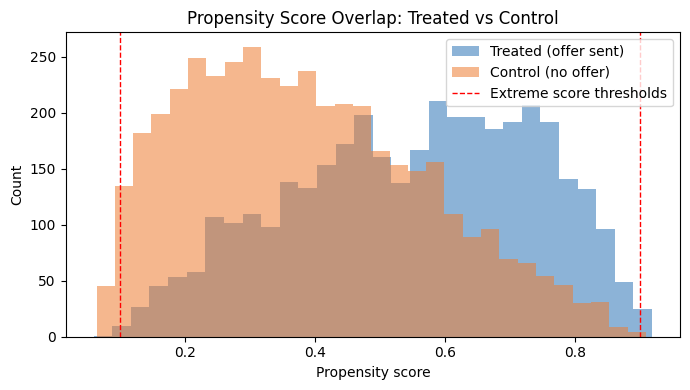

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(treated['propensity'], bins=30, alpha=0.55, label='Treated (offer sent)', color='#2E75B6')
ax.hist(control['propensity'], bins=30, alpha=0.55, label='Control (no offer)',   color='#ED7D31')
ax.axvline(0.1, color='red', linestyle='--', linewidth=1, label='Extreme score thresholds')
ax.axvline(0.9, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Propensity score'); ax.set_ylabel('Count')
ax.set_title('Propensity Score Overlap: Treated vs Control')
ax.legend(); plt.tight_layout(); plt.show()

## Assessment

**Overlap:** The propensity score distributions show substantial overlap between
treated and control groups across the 0.15–0.85 range. No extreme concentration
near 0 or 1. A propensity-adjusted analysis is feasible.

**Most imbalanced covariate: `household_size` (SMD ≈ 0.606)**
Treated users have substantially larger households — about 0.6 standard deviations
above the control group mean. The company targeted household-appropriate offers to
larger households, introducing systematic selection bias. Without adjustment, any
observed conversion difference mixes the offer effect with the household size effect.

**`prior_orders` is also imbalanced (SMD ≈ 0.524)**, indicating users with more
prior engagement were more likely to receive the offer. Highly engaged users upgrade
regardless of the offer, further inflating the naive estimate.

**Conclusion:** IPW adjustment is warranted to address household_size and prior_orders
imbalance. `weekly_app_sessions` shows minor imbalance (SMD ≈ 0.12), worth monitoring.
